# 중고차 가격 예측 데이터셋(Vehicle dataset)
- 중고차의 여러 특징(연식, 주행거리, 연료 타입, 판매자 유형 등)을 바탕으로 중고차 판매 가격(Selling_Price)을 예측하는 회귀(Regression) 모델 구축을 위한 데이터셋입니다

## 2. 컬럼 상세
| 컬럼명 | 데이터 타입 | 의미 및 설명 |
| :--- | :--- | :--- |
| **Car_Name** | String (Object) | 차량 모델 이름 (예: ritz, sx4, ciaz, wagon r, swift, city, brio 등) |
| **Year** | Integer (int64) | 차량 출고 연도 / 연식 (예: 2014, 2017 등) |
| **Selling_Price (타겟)** | Float (float64) | 중고차 현재 판매 가격 (단위: Lakh - 10만 루피) |
| **Present_Price** | Float (float64) | 차량의 신차 출고 당시 가격 (단위: Lakh - 10만 루피) |
| **Kms_Driven** | Integer (int64) | 누적 주행거리 (단위: km) |
| **Fuel_Type** | String (Categorical) | 사용 연료 종류 (Petrol: 가솔린, Diesel: 디젤, CNG: 압축천연가스) |
| **Seller_Type** | String (Categorical) | 판매자 유형 (Dealer: 딜러 매매, Individual: 개인 직거래) |
| **Transmission** | String (Categorical) | 변속기 방식 (Manual: 수동변속기, Automatic: 자동변속기) |
| **Owner** | Integer (int64) | 이전 소유자 수 / 명의 변경 횟수 (0: 첫 번째 소유자, 1: 1회 변경 등) |

[중고차 가격 예측 데이터셋 공식 링크](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?utm_source=gemini)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r"C:\kdt_0900_pjh\machine_learning\resource\datasets"
file_name = r"car_data.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
car_df = df.drop("Car_Name", axis=1)
car_df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# 수치형: Year, Selling_Price, Present_Price, Kms_Driven, Owner
# 분류형: Fuel_Type, Seller_Type, Transmission
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Kms_Driven     301 non-null    int64  
 4   Fuel_Type      301 non-null    object 
 5   Seller_Type    301 non-null    object 
 6   Transmission   301 non-null    object 
 7   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 18.9+ KB


In [5]:
car_df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


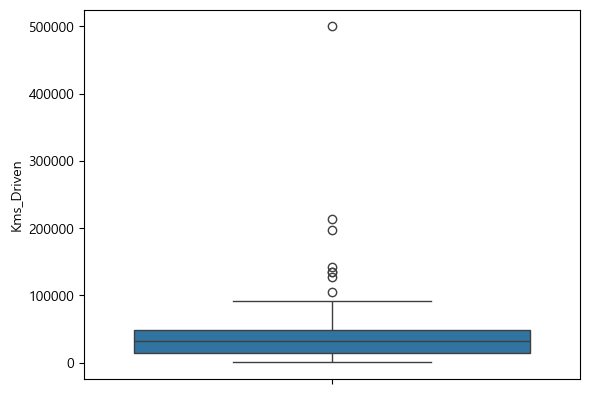

In [6]:
sns.boxplot(car_df, y="Kms_Driven")
plt.show()

In [7]:
car_df = car_df[car_df["Kms_Driven"] < 100000].copy().reset_index(drop=True)
car_df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
288,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
289,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
290,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
291,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


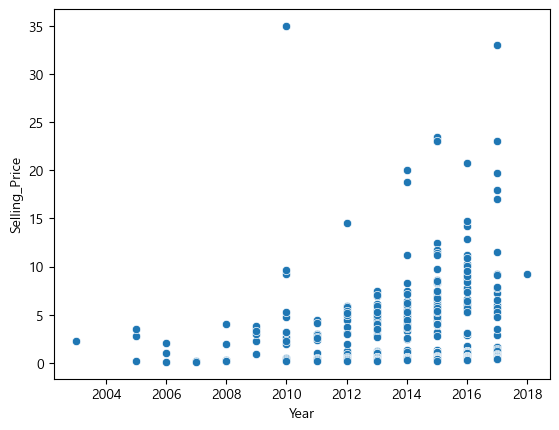

In [8]:
sns.scatterplot(car_df, x="Year", y="Selling_Price")
plt.show()

In [9]:
# 2020년을 기준으로 파생변수 생성
car_df["Vehicle_Age"] = 2020 - car_df["Year"]
car_df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,6
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,7
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,3
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,9
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,6


In [10]:
car_df = car_df[car_df["Fuel_Type"] != "CNG"].copy()
car_df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    234
Diesel     57
Name: count, dtype: int64

## 원핫 인코딩

In [11]:
column = car_df.columns
car_df = pd.get_dummies(car_df, columns=["Fuel_Type", "Seller_Type", "Transmission"], drop_first=True, dtype=int)

In [12]:
car_df.columns = car_df.columns.str.strip()
car_df

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,6,1,0,1
1,2013,4.75,9.54,43000,0,7,0,0,1
2,2017,7.25,9.85,6900,0,3,1,0,1
3,2011,2.85,4.15,5200,0,9,1,0,1
4,2014,4.60,6.87,42450,0,6,0,0,1
...,...,...,...,...,...,...,...,...,...
288,2016,9.50,11.60,33988,0,4,0,0,1
289,2015,4.00,5.90,60000,0,5,1,0,1
290,2009,3.35,11.00,87934,0,11,1,0,1
291,2017,11.50,12.50,9000,0,3,0,0,1


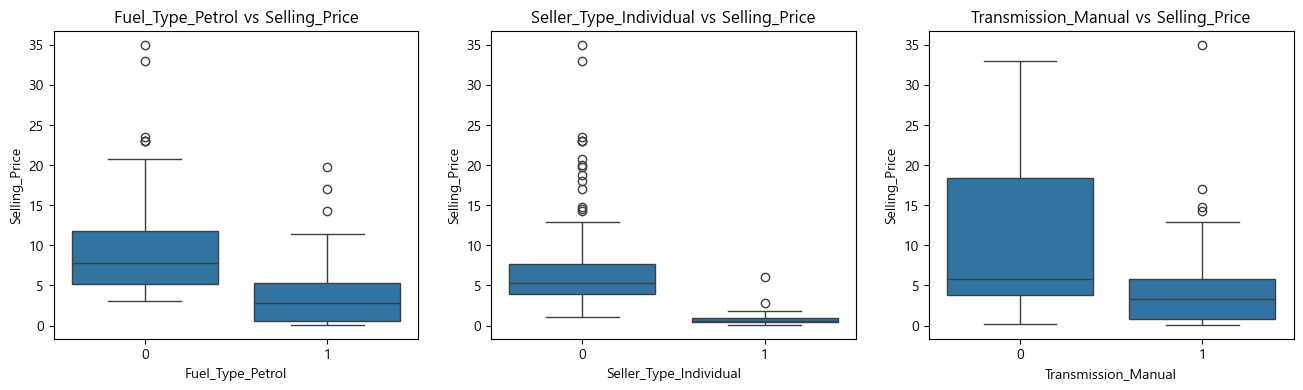

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(ax=axes[0], data=car_df, x="Fuel_Type_Petrol", y="Selling_Price")
axes[0].set_title("Fuel_Type_Petrol vs Selling_Price")

sns.boxplot(ax=axes[1], data=car_df, x="Seller_Type_Individual", y="Selling_Price")
axes[1].set_title("Seller_Type_Individual vs Selling_Price")

sns.boxplot(ax=axes[2], data=car_df, x="Transmission_Manual", y="Selling_Price")
axes[2].set_title("Transmission_Manual vs Selling_Price")

plt.show()

In [14]:
corr_matrix = car_df.corr()
corr_matrix

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
Year,1.000000,0.232067,-0.029342,-0.591753,-0.126058,-1.000000,-0.075838,-0.014822,-0.075008
Selling_Price,0.232067,1.000000,0.886872,0.123906,-0.100571,-0.232067,-0.541859,-0.568572,-0.372861
Present_Price,-0.029342,0.886872,1.000000,0.346668,-0.092067,0.029342,-0.459072,-0.542996,-0.316527
Kms_Driven,-0.591753,0.123906,0.346668,1.000000,-0.011859,0.591753,-0.293944,-0.355938,0.017111
Owner,-0.126058,-0.100571,-0.092067,-0.011859,1.000000,0.126058,0.045573,0.100228,0.069753
Vehicle_Age,-1.000000,-0.232067,0.029342,0.591753,0.126058,1.000000,0.075838,0.014822,0.075008
Fuel_Type_Petrol,-0.075838,-0.541859,-0.459072,-0.293944,0.045573,0.075838,1.000000,0.359843,0.083699
Seller_Type_Individual,-0.014822,-0.568572,-0.542996,-0.355938,0.100228,0.014822,0.359843,1.000000,0.092048
Transmission_Manual,-0.075008,-0.372861,-0.316527,0.017111,0.069753,0.075008,0.083699,0.092048,1.000000


<Axes: >

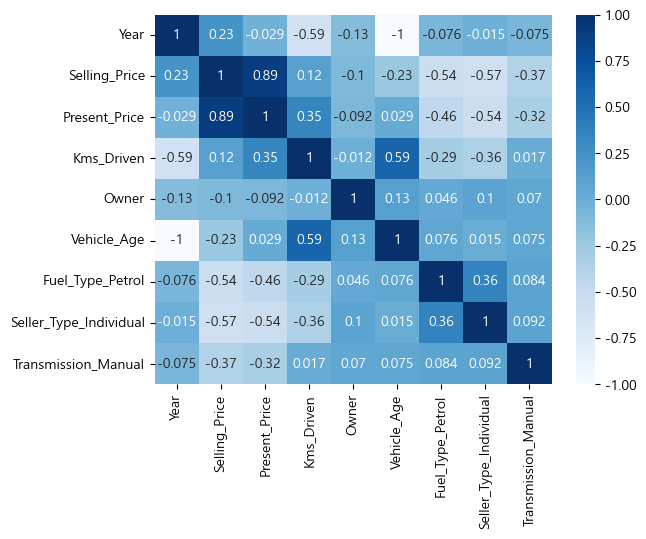

In [15]:
sns.heatmap(corr_matrix, cmap="Blues", annot=True)

In [16]:
car_df.drop("Year", axis=1, inplace=True)
car_df

,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,1,0,1
1,4.75,9.54,43000,0,7,0,0,1
2,7.25,9.85,6900,0,3,1,0,1
3,2.85,4.15,5200,0,9,1,0,1
4,4.60,6.87,42450,0,6,0,0,1
...,...,...,...,...,...,...,...,...
288,9.50,11.60,33988,0,4,0,0,1
289,4.00,5.90,60000,0,5,1,0,1
290,3.35,11.00,87934,0,11,1,0,1
291,11.50,12.50,9000,0,3,0,0,1


In [17]:
X = car_df.drop("Selling_Price", axis=1)
X.head()

,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,5.59,27000,0,6,1,0,1
1,9.54,43000,0,7,0,0,1
2,9.85,6900,0,3,1,0,1
3,4.15,5200,0,9,1,0,1
4,6.87,42450,0,6,0,0,1


In [18]:
y = car_df["Selling_Price"]
y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [19]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

[2.1433076549218777,
 7.144667275239435,
 1.072065374632327,
 11.410259365211015,
 5.207197026301815,
 2.2216299186754545,
 5.639754058168289]

## 트리
   - 계층적으로 자료를 표현할 때 적합한 자료구조
   - 데이터를 순차적으로 저장하지 않기 때문에 비선형 자료구조
   - 트리 내에 또 다른 트리가 있는 재귀적 자료구조
   - 하나의 루트 노드와 0개 이상의 하위 트리로 작성됨

### 트리의 사용 예시
   - 계층적 데이터 저장: 파일 및 폴더
   - 효율적인 검색속도: 효율적인 삽입, 삭제, 검색을 위해 사용
   - 데이터 베이스 인덱싱 구현
   - 힙(Heap)

### 트리 용어 정리 
   - 루트(Root)노드 : 트리의 가장 높은 곳에 있는 노드
   - 모든 노드는 루트노드의 서브트리에 속한다
   - 리프(Leaf)노드 : 트리의 가장 하단에 있는 노드
   - 자식노드가 없는 노드
   - 자식(Child)노드 : 동일한 부모를 가진 노드들을 의미함
   - 리프노드가 아닌 자식이 있는 노드 = 내부(Internal)노드, 비 단말(Non-Terminal)노드
   - 형제(Sibling)노드 : 동일한 부모를 가진 노드들을 의미한다
   - 조상(ancestro)노드 :  루트까지 경로상에 있는 모든 노드들의 집합
   - 후손(Descendant)노드 : 노드 아래로 매달린 모든 노드들의 집합
   - 서브트리(Subtree)노드 : 노드 자신과 후손 노드로 구성된 트리
   - 차수(Degree) : 어떤 노드가 가지고 있는 자식의 수
   - 레벨(Level) : 루트에서 얼마나 멀리 떨어져 있는지를 나타내는 것
   - 키(Key) : 탐색에 사용되는 노드에 저장된 정보

<img src="https://i.namu.wiki/i/8pViDtKiYxEmcz1zj2WHZEpLHeu4q4n1bAjOOTvA4rLde3d-miR4lbCeFRjhzuTV1SLW5vFdg81Q6vb6fm1I9Q.webp" style="width:800px;"/>

## 결정 트리(Decision Tree)란?
- 결정 트리는 데이터에 숨겨져 있는 규칙을 컴퓨터가 스스로 찾아내어, 마치 스무고개(IF-ELSE) 게임처럼 나무 가지를 뻗으며 정답을 찾아가는 지도학습(Supervised Learning) 알고리즘입니다.
- 한 줄 결론, 구간의 평균값으로 그 값을 예측하게 만든다.

| 구분 | 결정 트리 분류 (Classifier) | 결정 트리 회귀 (Regressor) |
| :--- | :--- | :--- |
| 목적 | 데이터가 어떤 그룹/카테고리에 속하는지 분류 | 데이터의 연속된 실숫값(수치)을 예측 |
| 예시 | 이 손님이 가방을 `산다(1)` / `안 산다(0)` | 오늘 특정 시간대에 따릉이가 `몇 대` 대여될까? |
| 최종 정답 결정 방식 | 다수결의 원칙<br>(마지막 방에 더 많은 쪽으로 분류) | 평균값 계산<br>(마지막 방에 모인 수치들의 평균을 내어 예측) |

### 2. 작동 원리 (데이터가 분리되는 과정)
1. 뿌리 노드 (Root Node): 전체 데이터가 시작되는 지점입니다.
2. 중간 노드 (Internal Node): 컴퓨터가 불순도를 낮추기 위해 최적의 질문(예: `Hour <= 17`)을 던져 데이터를 두 갈래로 쪼갭니다.
3. 최종 노드 (Leaf Node): 더 이상 쪼개지지 않는 마지막 나뭇잎 방입니다. 
   * 분류: 이 방에 모인 데이터 중 가장 많은 클래스가 최종 정답이 됩니다.
   * 회귀: 이 방에 모인 데이터들의 평균값이 최종 예측 숫자가 됩니다.

### 3. 장점과 단점
* 장점:
  * 시각화했을 때 컴퓨터가 왜 이런 판단을 내렸는지 사람이 눈으로 로직을 완벽히 이해할 수 있습니다. (설명 가능성 높음)
  * 데이터의 스케일링(정규화) 같은 전처리 작업의 영향을 거의 받지 않아 편리합니다.
* 단점:
  * 조건을 무한정 만들게 놔두면 훈련 데이터에만 완벽하게 맞아떨어지는 과적합(Overfitting)에 매우 취약합니다.
  * 해결책: 나무의 최대 깊이를 제한하는 가지치기(pruning) `max_depth` 같은 하이퍼파라미터 조율이 필수적입니다.

![](https://drive.google.com/thumbnail?id=1V1M-BXjutvDlwOhw6bUW-Zlh1J0etHpC&sz=w1000)

### 결정 트리 수행 순서
1. 최적의 특성(feature)과 분할 기준(threshold)을 찾아 첫 번째 분할을 수행
2. 만약 분류라면
   - Gini 불순도(Gini Impurity)
   - 엔트로피(Entropy)

4. 만약 회귀라면
   - 평균 제곱 오차(Mean Squared Error, MSE)
   - 절대 평균 오차(Mean Absolute Error

5. 각 하위 노드에 대해 위 단계를 반복하고 이 과정으로 여러 깊이로 설정합니다
6. 모든 노드가 더이상 나눌 수 없거나 특정 조건을 만족할 떄까지 반복합니다
7. 더 이상 분할이 불가능할 때 리프 노트가 생성됩니다
   - 분류 문제: 가장 많은 클래스가 있는 클래스를 예측값으로 사용
   - 회귀 문제: 평균값을 예측값으로 사용

#### Gini 불순도(Gini Impurity)
- 한 노드에 데이터 순수도(Purity)를 측정하는 지표입니다. 한 노드에 있는 샘플들이 동일한 클래스에 속할 확률이 높을수록 Gini 불순도가 낮아집니다
- 즉 노드가 얼마나 섞여있는지 나타내는 지표입니다.

#### 엔트로피(Entropy)
- 정보의 불확실성(혼란도)를 측정합니다. 엔트로피가 높을 수록 해당 노드에 데이터가 더 섞여있으며 예측하기 어렵습니다.
- 데이터가 균등하게 분포될 때 최대값을 가집니다.

### 예시 데이터프레임 (온도, 습도, 운동량)
- 아래 데이터가 있다고 가정해보자.

| 샘플 번호 | 온도 (°C) | 습도 (%) | 운동량 (Target, 분) |
| :---: | :---: | :---: | :---: |
| #1 | 15 | 40 | **60** |
| #2 | 18 | 45 | **55** |
| #3 | 28 | 75 | **20** |
| #4 | 30 | 80 | **15** |
| #5 | 32 | 85 | **10** |

### 1. 분산을 구한다
* **대상 데이터 (운동량):** `[60, 55, 20, 15, 10]` (총 5개)
* **평균 ($\mu$):** $(60 + 55 + 20 + 15 + 10) / 5 = \mathbf{32}$
* **분산 ($\sigma^2$):** 각 데이터에서 평균(32)을 뺀 뒤 제곱한 값들의 평균
  $$((60-32)^2 + (55-32)^2 + (20-32)^2 + (15-32)^2 + (10-32)^2) / 5$$
  $$= (784 + 529 + 144 + 289 + 484) / 5 = \mathbf{446}$$

- **처음 상태:** 운동량의 평균은 **32**, 분산(오차 위험도)은 **446**인 상태에서 출발합니다.

### 2. 운동량 평균 32에 해당하는 기준으로 중간 값후보에 등록한다.
예를 들어 습도를 골랐다면
* **#2 샘플:** 45%
* **#3 샘플:** 75%
- 45%와 75%의 딱 중간인 **60%** `(45 + 75) / 2` 가 칼날 후보가 된다.

- 왼쪽 그룹: 60보다 작은 그룹(40, 45)
- 오른쪽 그룹: 60보다 큰 그룹(75, 80, 85)

### 3. 왼쪽 그룹과 오른쪽 그룹 각각의 분산을 구한다
#### 1) 왼쪽 그룹 (습도 60% 미만: 40%, 45%)
* **대상 운동량:** `[60, 55]`
* **평균:** $(60 + 55) / 2 = \mathbf{57.5}$
* **분산 식:**
  $$\text{왼쪽 분산} = \frac{(60 - 57.5)^2 + (55 - 57.5)^2}{2}$$
  $$\text{왼쪽 분산} = \frac{(2.5)^2 + (-2.5)^2}{2} = \frac{6.25 + 6.25}{2} = \mathbf{6.25}$$

#### 2) 오른쪽 그룹 (습도 60% 이상: 75%, 80%, 85%)
* **대상 운동량:** `[20, 15, 10]`
* **평균:** $(20 + 15 + 10) / 3 = \mathbf{15}$
* **분산 식:**
  $$\text{오른쪽 분산} = \frac{(20 - 15)^2 + (15 - 15)^2 + (10 - 15)^2}{3}$$
  $$\text{오른쪽 분산} = \frac{(5)^2 + (0)^2 + (-5)^2}{3} = \frac{25 + 0 + 25}{3} = \frac{50}{3} \approx \mathbf{16.67}$$

* **가중 분산 합 공식:**
  $$\text{자식 노드 분산 합} = \left( \frac{\text{왼쪽 데이터 수}}{\text{전체 데이터 수}} \times \text{왼쪽 분산} \right) + \left( \frac{\text{오른쪽 데이터 수}}{\text{전체 데이터 수}} \times \text{오른쪽 분산} \right)$$

* **실제 계산 식:**
  $$\text{자식 노드 분산 합} = \left( \frac{2}{5} \times 6.25 \right) + \left( \frac{3}{5} \times 16.67 \right)$$
  $$\text{자식 노드 분산 합} = 2.5 + 10 = \mathbf{12.5}$$

### 4. 최종 분산 감소량을 구한다

이제 처음에 구했던 부모 노드의 분산(446)에서 방금 구한 자식들의 분산 합(12.5)을 빼서 이 칼날(습도 60%)의 최종 점수를 매깁니다.

$$\text{분산 감소량} = \text{부모 분산} - \text{자식 분산 합}$$
$$\text{분산 감소량} = 446 - 12.5 = \mathbf{433.5}$$

### 5. 모든 컬럼의 값들을 계산하고 최종 분산 감소량이 가장 큰 값들만 선택하여 데이터가 1개가 될 때까지 나눈다.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(232, 7) (59, 7) (232,) (59,)


In [21]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [22]:
from sklearn.tree import DecisionTreeRegressor

In [23]:
dtr = DecisionTreeRegressor(random_state=2026)

In [24]:
dtr.fit(X_train_s, y_train)

DecisionTreeRegressor(random_state=2026)

In [25]:
y_pred1 = dtr.predict(X_test_s)
print(y_pred1)

[ 5.25  6.25  1.1   5.25  1.15  0.3   0.45  4.5   4.75  2.65  7.45  0.25
  0.3   3.95  5.4   6.95  2.    6.6   8.4   0.12  6.4   0.5  11.25  2.55
  0.75  0.75  6.4   5.5   0.4   0.65  0.15  4.75  0.48  8.25  1.15  2.65
  5.9   1.95  4.75  5.4   0.5   4.15  4.15  5.3   5.4   0.16  0.78  3.9
 12.9   1.1   2.7   5.5   0.72  4.75  4.95  0.38  0.6   8.4   4.75]


In [26]:
# 주의사항
# 회위는 예측 문제이므로 두 개의 값이 일치하는지 아닌지 정확도를 평가하면 안된다.
# dtr.scor(X_test, y_pred1)

### 회귀문제의 모델 평가
| 지표 | 수식 | 특징 | 장점 | 단점 |
| :---: | :---: | :--- | :--- | :--- |
| **MAE** | $\frac{1}{n}\sum\|y - \hat{y}\|$ | 절대값 오차의 평균 | 직관적이며, **이상치(Outlier)에 강인**함 | 느린 최적화, 미분이 불가능한 지점 존재 |
| **MSE** | $\frac{1}{n}\sum(y - \hat{y})^2$ | 제곱 오차의 평균 | 미분이 매끄러워 **가장 많이 사용**됨 | 오차가 클수록 제곱되어 **이상치에 민감**함 |
| **RMSE** | $\sqrt{\text{MSE}}$ | 제곱 오차 평균의 제곱근 | **원래 데이터와 단위가 일치**하여 직관적임 | 결국 MSE 기반이라 이상치의 영향을 받음 |

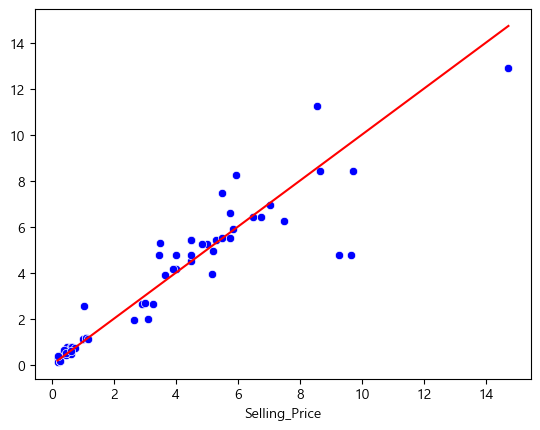

In [27]:
sns.scatterplot(x=y_test, y=y_pred1, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")

In [28]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error

In [29]:
mse = mean_squared_error(y_test, y_pred1)
rmse = root_mean_squared_error(y_test, y_pred1)
print(f"RMSE: {rmse}")

RMSE: 1.1793764511636315


In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
lr = LinearRegression()

In [32]:
lr.fit(X_train_s, y_train)

LinearRegression()

In [33]:
y_pred2 = lr.predict(X_test_s)
y_pred2[:5]

array([ 4.61187633,  8.87616827, -0.4125723 ,  6.79632359,  1.20000392])

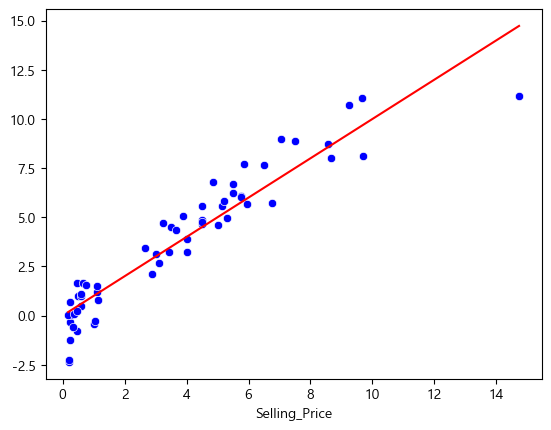

In [34]:
sns.scatterplot(x=y_test, y=y_pred2, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")

In [35]:
rmse2 = root_mean_squared_error(y_test, y_pred2)
print(f"결정트리: {rmse}")
print(f"선형모델: {rmse2}")

결정트리: 1.1793764511636315
선형모델: 1.1073053305563636


In [36]:
# 규제
dtr = DecisionTreeRegressor(max_depth=60, min_samples_leaf=40)

In [37]:
dtr = dtr.fit(X_train_s, y_train)

In [38]:
y_pred3 = dtr.predict(X_test_s)

In [39]:
rmse3 = root_mean_squared_error(y_test, y_pred3)

print(f"규제 적용 RMSE: {rmse3}")

규제 적용 RMSE: 2.0986541062585533


In [40]:
from sklearn.tree import plot_tree

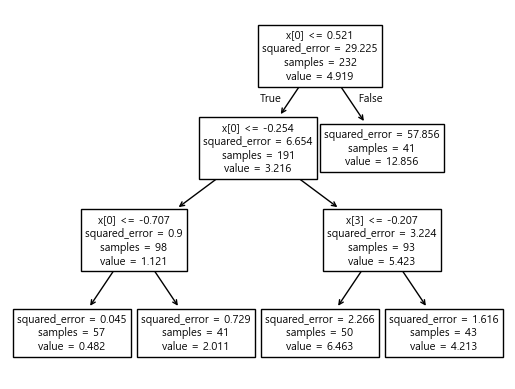

In [41]:
plot_tree(dtr)
plt.show()

# 랜덤 포레스트(RandomForestRegressor)
- "나무(결정 트리) 한 개는 과적합되기 쉬우니, 서로 다른 나무 100개를 만들어 그들의 예측값을 평균 내자!"
- 즉 결정트리의 상위 버전

## 핵심 하이퍼파라미터
* `n_estimators`: 숲에 심을 **나무의 개수** (기본값 100개, 많을수록 좋지만 무거워짐)
* `max_depth`, `min_samples_split` 등: 기존 결정 트리의 규제 파라미터와 완전히 동일하게 나무 각각에 적용됨

In [50]:
from sklearn.ensemble import RandomForestRegressor

In [51]:
rf = RandomForestRegressor(random_state=2026)

In [53]:
rf = rf.fit(X_train_s, y_train)

In [54]:
y_pred4 = rf.predict(X_test_s)
y_pred4

array([ 5.5272,  7.1241,  1.073 ,  5.1795,  1.1635,  0.2951,  0.496 ,
        4.6847,  4.384 ,  2.6795,  6.8555,  0.2892,  0.3495,  4.2895,
        4.9295,  7.1935,  2.871 ,  5.6505,  9.0106,  0.1736,  6.5555,
        0.5194, 11.1655,  2.3   ,  0.5854,  0.606 ,  6.6515,  4.9265,
        0.4345,  0.4245,  0.2181,  5.341 ,  0.5641,  7.5425,  1.188 ,
        2.5325,  6.3995,  2.929 ,  4.248 ,  4.4265,  0.5276,  4.243 ,
        3.98  ,  4.571 ,  5.012 ,  0.2126,  0.6853,  4.112 , 11.8691,
        1.125 ,  2.6535,  5.634 ,  0.654 ,  7.0769,  4.989 ,  0.3631,
        0.6211,  9.5456,  7.0559])

In [64]:
rf.score(X_test, y_test)

C:\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


-32.94378369107475

In [56]:
from sklearn.metrics import root_mean_squared_error

In [57]:
rmse = root_mean_squared_error(y_pred4, y_test)
print(f"랜덤 포레스트: {rmse}")

랜덤 포레스트: 0.814522899450233


In [59]:
rf.feature_importances_

array([9.02056788e-01, 1.81574128e-02, 1.32119797e-05, 6.92772495e-02,
       3.31736014e-03, 3.90138020e-03, 3.27659781e-03])

In [63]:
feature_imp = pd.DataFrame({
    "Feaures": X_train.columns,
    "importances": rf.feature_importances_
}).sort_values(by="importances", ascending=False)
feature_imp

,Feaures,importances
0,Present_Price,0.902057
3,Vehicle_Age,0.069277
1,Kms_Driven,0.018157
5,Seller_Type_Individual,0.003901
4,Fuel_Type_Petrol,0.003317
6,Transmission_Manual,0.003277
2,Owner,0.000013


<Axes: xlabel='Feaures', ylabel='importances'>

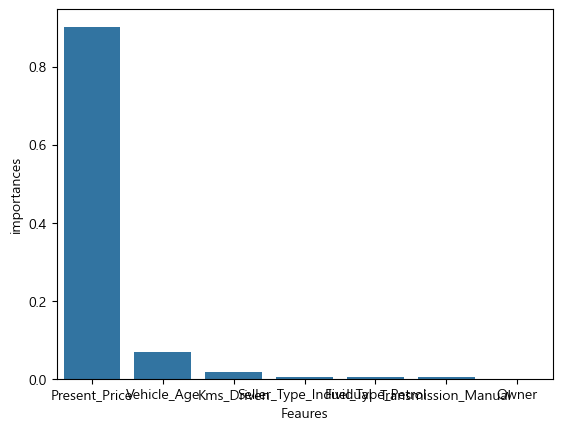

In [65]:
sns.barplot(feature_imp, x="Feaures", y="importances")